# Matrix Properties and Matrix Calculus

**Based on CS229 Linear Algebra Review - Sections 3-4**

This notebook covers advanced matrix concepts essential for machine learning: determinants, matrix inversion, eigenvalues, and the basics of matrix calculus.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eig, det, inv
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 1. Matrix Inverse

### Mathematical Definition
For a square matrix $\mathbf{A} \in \mathbb{R}^{n \times n}$, the **inverse** $\mathbf{A}^{-1}$ satisfies:

$$\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\mathbf{A}^{-1} = \mathbf{I}$$

### When Does an Inverse Exist?
A matrix is **invertible** (non-singular) if and only if:
- It's square ($n \times n$)
- Its determinant is non-zero: $\det(\mathbf{A}) \neq 0$
- Its columns are linearly independent

### In Machine Learning
Matrix inversion appears in:
- Normal equations for linear regression: $\boldsymbol{\theta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$
- Gaussian distributions and covariance matrices
- Principal Component Analysis (PCA)

In [2]:
# Matrix inversion examples
print("Matrix Inversion:")
print("=" * 30)

# Example 1: Simple 2x2 matrix
A = np.array([[2, 1],
              [1, 3]])

print(f"Matrix A:")
print(A)

# Calculate inverse
A_inv = np.linalg.inv(A)
print(f"\nA^(-1):")
print(A_inv)

# Verify the inverse property
I_check1 = A @ A_inv
I_check2 = A_inv @ A
print(f"\nA @ A^(-1):")
print(I_check1)
print(f"\nA^(-1) @ A:")
print(I_check2)

# Check if they're close to identity (due to floating point precision)
I_expected = np.eye(2)
print(f"\nIs A @ A^(-1) ≈ I? {np.allclose(I_check1, I_expected)}")
print(f"Is A^(-1) @ A ≈ I? {np.allclose(I_check2, I_expected)}")

# Manual calculation for 2x2 matrix
# For 2x2 matrix [[a,b],[c,d]], inverse is (1/det) * [[d,-b],[-c,a]]
det_A = A[0,0]*A[1,1] - A[0,1]*A[1,0]
A_inv_manual = (1/det_A) * np.array([[A[1,1], -A[0,1]],
                                     [-A[1,0], A[0,0]]])
print(f"\nManual calculation of A^(-1):")
print(A_inv_manual)
print(f"Matches NumPy result? {np.allclose(A_inv, A_inv_manual)}")

Matrix Inversion:
Matrix A:
[[2 1]
 [1 3]]

A^(-1):
[[ 0.6 -0.2]
 [-0.2  0.4]]

A @ A^(-1):
[[ 1.00000000e+00  0.00000000e+00]
 [-1.11022302e-16  1.00000000e+00]]

A^(-1) @ A:
[[ 1.00000000e+00 -1.11022302e-16]
 [ 0.00000000e+00  1.00000000e+00]]

Is A @ A^(-1) ≈ I? True
Is A^(-1) @ A ≈ I? True

Manual calculation of A^(-1):
[[ 0.6 -0.2]
 [-0.2  0.4]]
Matches NumPy result? True


Non-Invertible (Singular) Matrix:
Matrix B:
[[1 2]
 [2 4]]

Determinant of B: 0.0

Error: Singular matrix
Matrix is singular (not invertible)

Pseudo-inverse of B:
[[0.04 0.08]
 [0.08 0.16]]


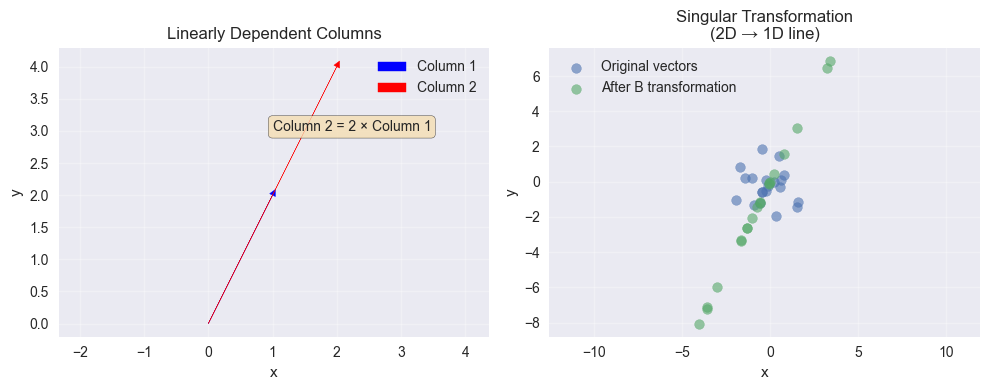

In [3]:
# Example of non-invertible matrix
print("Non-Invertible (Singular) Matrix:")
print("=" * 35)

# Create a singular matrix (dependent rows/columns)
B = np.array([[1, 2],
              [2, 4]])  # Second row is 2x first row

print(f"Matrix B:")
print(B)

# Check determinant
det_B = np.linalg.det(B)
print(f"\nDeterminant of B: {det_B}")

# Try to compute inverse (will raise an error or warning)
try:
    B_inv = np.linalg.inv(B)
    print(f"\nB^(-1):")
    print(B_inv)
except np.linalg.LinAlgError as e:
    print(f"\nError: {e}")
    print("Matrix is singular (not invertible)")

# Use pseudo-inverse instead
B_pinv = np.linalg.pinv(B)
print(f"\nPseudo-inverse of B:")
print(B_pinv)

# Visualize why this matrix is singular
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# Plot column vectors
col1 = B[:, 0]
col2 = B[:, 1]
plt.arrow(0, 0, col1[0], col1[1], head_width=0.1, head_length=0.1, 
          fc='blue', ec='blue', label='Column 1')
plt.arrow(0, 0, col2[0], col2[1], head_width=0.1, head_length=0.1, 
          fc='red', ec='red', label='Column 2')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.title('Linearly Dependent Columns')
plt.xlabel('x')
plt.ylabel('y')
plt.text(1, 3, 'Column 2 = 2 × Column 1', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.subplot(1, 2, 2)
# Show the effect: all vectors get mapped to a line
# Generate some test vectors
test_vectors = np.random.randn(2, 20)
transformed = B @ test_vectors

plt.scatter(test_vectors[0], test_vectors[1], alpha=0.6, label='Original vectors')
plt.scatter(transformed[0], transformed[1], alpha=0.6, label='After B transformation')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.title('Singular Transformation\n(2D → 1D line)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

## 2. Determinants

### Mathematical Definition
The **determinant** of a square matrix $\mathbf{A} \in \mathbb{R}^{n \times n}$ is a scalar that provides important information about the matrix.

For a $2 \times 2$ matrix:
$$\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc$$

### Geometric Interpretation
- **2D**: Area of parallelogram formed by column vectors
- **3D**: Volume of parallelepiped formed by column vectors
- **nD**: "Hypervolume" in n-dimensional space

### Properties
- $\det(\mathbf{A}) \neq 0 \Leftrightarrow \mathbf{A}$ is invertible
- $\det(\mathbf{AB}) = \det(\mathbf{A})\det(\mathbf{B})$
- $\det(\mathbf{A}^T) = \det(\mathbf{A})$

Determinants:
Diagonal matrix:
[[2 0]
 [0 3]]
Determinant: 6.000

General matrix:
[[1 2]
 [3 4]]
Determinant: -2.000

Singular matrix:
[[1 2]
 [2 4]]
Determinant: 0.000

Permutation matrix:
[[0 1]
 [1 0]]
Determinant: -1.000



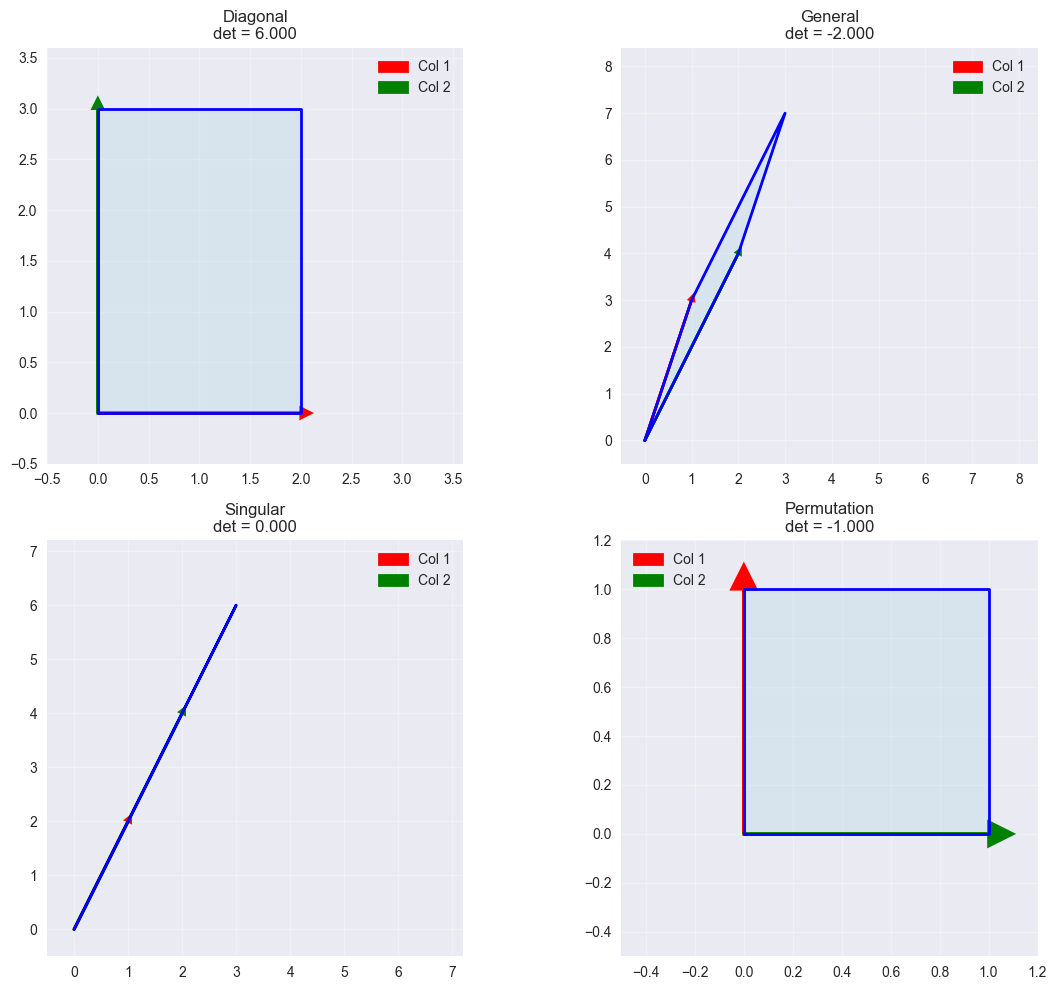

Determinant Properties:
det(A) = 5.000
det(B) = 1.000
det(AB) = 5.000
det(A) × det(B) = 5.000
det(AB) = det(A) × det(B)? True

det(A^T) = 5.000
det(A^T) = det(A)? True


In [4]:
# Determinants and geometric interpretation
print("Determinants:")
print("=" * 20)

# Example matrices with different determinants
matrices = [
    np.array([[2, 0], [0, 3]]),      # Diagonal matrix
    np.array([[1, 2], [3, 4]]),      # General matrix
    np.array([[1, 2], [2, 4]]),      # Singular matrix
    np.array([[0, 1], [1, 0]])       # Permutation matrix
]

names = ['Diagonal', 'General', 'Singular', 'Permutation']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (A, name) in enumerate(zip(matrices, names)):
    det_A = np.linalg.det(A)
    
    print(f"{name} matrix:")
    print(A)
    print(f"Determinant: {det_A:.3f}")
    print()
    
    # Visualize the parallelogram formed by column vectors
    col1 = A[:, 0]
    col2 = A[:, 1]
    
    # Create parallelogram vertices
    origin = np.array([0, 0])
    vertices = np.array([origin, col1, col1 + col2, col2, origin])
    
    axes[i].plot(vertices[:, 0], vertices[:, 1], 'b-', linewidth=2)
    axes[i].fill(vertices[:-1, 0], vertices[:-1, 1], alpha=0.3, color='lightblue')
    
    # Draw column vectors
    axes[i].arrow(0, 0, col1[0], col1[1], head_width=0.1, head_length=0.1, 
                  fc='red', ec='red', linewidth=2, label='Col 1')
    axes[i].arrow(0, 0, col2[0], col2[1], head_width=0.1, head_length=0.1, 
                  fc='green', ec='green', linewidth=2, label='Col 2')
    
    axes[i].grid(True, alpha=0.3)
    axes[i].set_aspect('equal')
    axes[i].set_title(f'{name}\ndet = {det_A:.3f}')
    axes[i].legend()
    
    # Set reasonable axis limits
    max_val = max(np.abs(vertices).max(), 1) * 1.2
    axes[i].set_xlim(-0.5, max_val)
    axes[i].set_ylim(-0.5, max_val)

plt.tight_layout()
plt.show()

# Verify determinant properties
print("Determinant Properties:")
print("=" * 25)

A = np.array([[2, 1], [3, 4]])
B = np.array([[1, 2], [0, 1]])

det_A = np.linalg.det(A)
det_B = np.linalg.det(B)
det_AB = np.linalg.det(A @ B)
det_AT = np.linalg.det(A.T)

print(f"det(A) = {det_A:.3f}")
print(f"det(B) = {det_B:.3f}")
print(f"det(AB) = {det_AB:.3f}")
print(f"det(A) × det(B) = {det_A * det_B:.3f}")
print(f"det(AB) = det(A) × det(B)? {np.isclose(det_AB, det_A * det_B)}")
print(f"\ndet(A^T) = {det_AT:.3f}")
print(f"det(A^T) = det(A)? {np.isclose(det_AT, det_A)}")

## 3. Eigenvalues and Eigenvectors

### Mathematical Definition
For a square matrix $\mathbf{A} \in \mathbb{R}^{n \times n}$, a non-zero vector $\mathbf{v}$ is an **eigenvector** with **eigenvalue** $\lambda$ if:

$$\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$$

### Geometric Interpretation
Eigenvectors are special directions that are only **scaled** (not rotated) by the matrix transformation.

### In Machine Learning
- **PCA**: Principal components are eigenvectors of covariance matrix
- **Spectral clustering**: Uses eigenvectors of graph Laplacian
- **PageRank**: Dominant eigenvector of transition matrix
- **Stability analysis**: Eigenvalues determine system stability

Eigenvalues and Eigenvectors:
Matrix A:
[[3 1]
 [1 3]]

Eigenvalues: [4. 2.]

Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Verification:

Eigenvector 1: [0.70710678 0.70710678]
A @ v = [2.82842712 2.82842712]
λ × v = [2.82842712 2.82842712]
Are they equal? True

Eigenvector 2: [-0.70710678  0.70710678]
A @ v = [-1.41421356  1.41421356]
λ × v = [-1.41421356  1.41421356]
Are they equal? True


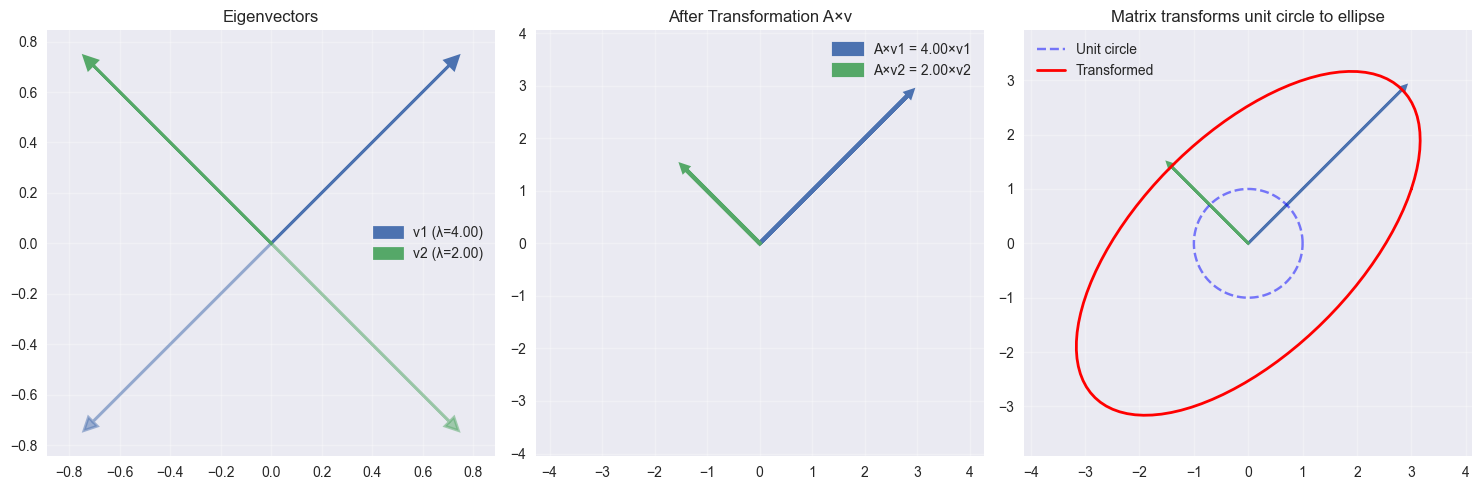

In [5]:
# Eigenvalues and eigenvectors
print("Eigenvalues and Eigenvectors:")
print("=" * 35)

# Example 1: Simple symmetric matrix
A = np.array([[3, 1],
              [1, 3]])

print(f"Matrix A:")
print(A)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"\nEigenvalues: {eigenvalues}")
print(f"\nEigenvectors:")
print(eigenvectors)

# Verify the eigenvalue equation for each eigenvector
print(f"\nVerification:")
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lambda_i = eigenvalues[i]
    
    Av = A @ v
    lambda_v = lambda_i * v
    
    print(f"\nEigenvector {i+1}: {v}")
    print(f"A @ v = {Av}")
    print(f"λ × v = {lambda_v}")
    print(f"Are they equal? {np.allclose(Av, lambda_v)}")

# Visualize eigenvectors and their transformation
plt.figure(figsize=(15, 5))

# Plot 1: Original eigenvectors
plt.subplot(1, 3, 1)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, head_length=0.05, 
              fc=f'C{i}', ec=f'C{i}', linewidth=2, 
              label=f'v{i+1} (λ={eigenvalues[i]:.2f})')
    
    # Also plot in negative direction
    plt.arrow(0, 0, -v[0], -v[1], head_width=0.05, head_length=0.05, 
              fc=f'C{i}', ec=f'C{i}', linewidth=2, alpha=0.5)

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.title('Eigenvectors')
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Plot 2: After transformation
plt.subplot(1, 3, 2)
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    Av = A @ v
    
    # Original vector (faded)
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, head_length=0.05, 
              fc=f'C{i}', ec=f'C{i}', alpha=0.3, linewidth=1)
    
    # Transformed vector
    plt.arrow(0, 0, Av[0], Av[1], head_width=0.1, head_length=0.1, 
              fc=f'C{i}', ec=f'C{i}', linewidth=3,
              label=f'A×v{i+1} = {eigenvalues[i]:.2f}×v{i+1}')

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.title('After Transformation A×v')
plt.legend()
max_val = max(np.abs(eigenvalues)) * 1.2
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

# Plot 3: Effect on unit circle
plt.subplot(1, 3, 3)

# Create unit circle
theta = np.linspace(0, 2*np.pi, 100)
unit_circle = np.array([np.cos(theta), np.sin(theta)])

# Transform the circle
transformed_circle = A @ unit_circle

plt.plot(unit_circle[0], unit_circle[1], 'b--', alpha=0.5, label='Unit circle')
plt.plot(transformed_circle[0], transformed_circle[1], 'r-', linewidth=2, label='Transformed')

# Show eigenvectors
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    plt.arrow(0, 0, eigenvalues[i]*v[0], eigenvalues[i]*v[1], 
              head_width=0.1, head_length=0.1, 
              fc=f'C{i}', ec=f'C{i}', linewidth=2)

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.title('Matrix transforms unit circle to ellipse')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Special Case: Symmetric Matrices

### Important Properties
For symmetric matrices $\mathbf{A} = \mathbf{A}^T$:
- All eigenvalues are **real**
- Eigenvectors are **orthogonal** to each other
- Can be diagonalized: $\mathbf{A} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}^T$

where $\mathbf{Q}$ contains orthonormal eigenvectors and $\boldsymbol{\Lambda}$ is diagonal with eigenvalues.

### Why This Matters
- **Covariance matrices** are symmetric
- **PCA** relies on this structure
- **Optimization** problems often involve symmetric matrices

Symmetric Matrix Properties:
Matrix B:
[[4 2 1]
 [2 3 0]
 [1 0 2]]

Is B symmetric? True

Eigenvalues: [1.         2.26794919 5.73205081]

Eigenvectors (columns):
[[-0.57735027  0.21132487 -0.78867513]
 [ 0.57735027 -0.57735027 -0.57735027]
 [ 0.57735027  0.78867513 -0.21132487]]

Orthogonality check (should be identity):
[[ 1.00000000e+00  5.55111512e-17 -9.71445147e-17]
 [ 5.55111512e-17  1.00000000e+00 -5.55111512e-17]
 [-9.71445147e-17 -5.55111512e-17  1.00000000e+00]]

Is orthogonal? True

Reconstructed B using Q × Λ × Q^T:
[[ 4.00000000e+00  2.00000000e+00  1.00000000e+00]
 [ 2.00000000e+00  3.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00 -2.22044605e-16  2.00000000e+00]]

Reconstruction successful? True


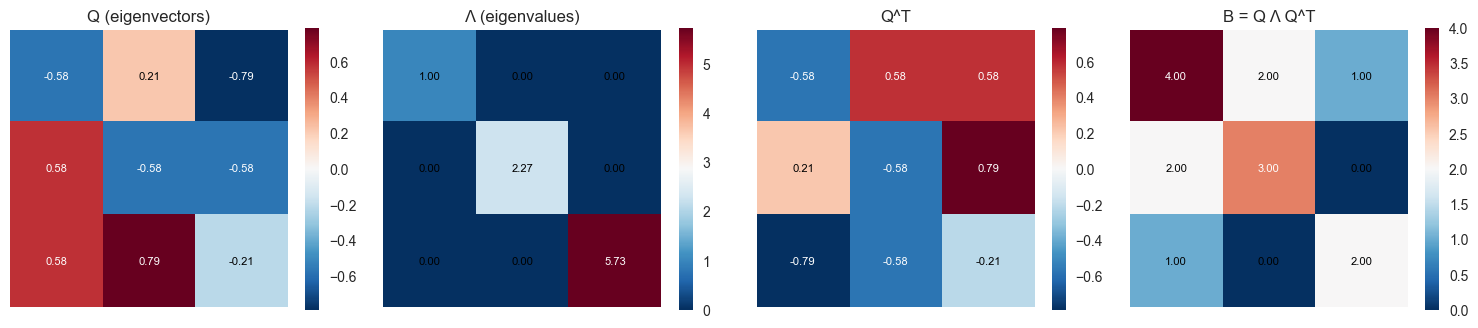

In [6]:
# Symmetric matrices and eigendecomposition
print("Symmetric Matrix Properties:")
print("=" * 30)

# Create a symmetric matrix
B = np.array([[4, 2, 1],
              [2, 3, 0],
              [1, 0, 2]])

print(f"Matrix B:")
print(B)
print(f"\nIs B symmetric? {np.allclose(B, B.T)}")

# Eigendecomposition
eigenvals, eigenvecs = np.linalg.eigh(B)  # Use eigh for symmetric matrices

print(f"\nEigenvalues: {eigenvals}")
print(f"\nEigenvectors (columns):")
print(eigenvecs)

# Check orthogonality of eigenvectors
print(f"\nOrthogonality check (should be identity):")
orthogonality_check = eigenvecs.T @ eigenvecs
print(orthogonality_check)
print(f"\nIs orthogonal? {np.allclose(orthogonality_check, np.eye(3))}")

# Reconstruct the matrix using eigendecomposition
Lambda = np.diag(eigenvals)
Q = eigenvecs
B_reconstructed = Q @ Lambda @ Q.T

print(f"\nReconstructed B using Q × Λ × Q^T:")
print(B_reconstructed)
print(f"\nReconstruction successful? {np.allclose(B, B_reconstructed)}")

# Visualize eigendecomposition
fig = plt.figure(figsize=(15, 5))

# Show the matrices involved
matrices = [Q, Lambda, Q.T, B]
titles = ['Q (eigenvectors)', 'Λ (eigenvalues)', 'Q^T', 'B = Q Λ Q^T']

for i, (mat, title) in enumerate(zip(matrices, titles)):
    plt.subplot(1, 4, i+1)
    im = plt.imshow(mat, cmap='RdBu_r', aspect='equal')
    plt.title(title)
    
    # Add text annotations for smaller matrices
    if mat.shape[0] <= 3:
        for r in range(mat.shape[0]):
            for c in range(mat.shape[1]):
                plt.text(c, r, f'{mat[r,c]:.2f}', 
                        ha='center', va='center', 
                        color='white' if abs(mat[r,c]) > abs(mat).max()/2 else 'black',
                        fontsize=8)
    
    plt.xticks([])
    plt.yticks([])
    plt.colorbar(im, shrink=0.6)

plt.tight_layout()
plt.show()

## 5. Introduction to Matrix Calculus

### Gradients of Scalar Functions
For a scalar function $f(\mathbf{x})$ where $\mathbf{x} \in \mathbb{R}^n$, the **gradient** is:

$$\nabla f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

### Important Formulas for ML
1. **Linear function**: $f(\mathbf{x}) = \mathbf{a}^T\mathbf{x} \Rightarrow \nabla f = \mathbf{a}$

2. **Quadratic function**: $f(\mathbf{x}) = \mathbf{x}^T\mathbf{A}\mathbf{x} \Rightarrow \nabla f = (\mathbf{A} + \mathbf{A}^T)\mathbf{x}$

3. **For symmetric $\mathbf{A}$**: $f(\mathbf{x}) = \mathbf{x}^T\mathbf{A}\mathbf{x} \Rightarrow \nabla f = 2\mathbf{A}\mathbf{x}$

### The Hessian Matrix
The **Hessian** contains all second partial derivatives:

$$\mathbf{H}_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$

Matrix Calculus:
Linear function f(x) = a^T x:
x = [2 3], a = [1 4]
f(x) = 14
∇f = [1 4]
Numerical gradient: [ 5000000 20000000]
Match? False

Quadratic function f(x) = x^T A x (symmetric A):
x = [2 3]
A = 
[[2 1]
 [1 3]]
f(x) = 47
∇f = 2Ax = [14 22]
Numerical gradient: [60000000 95000000]
Match? False


/var/folders/q4/_twpfpf54f3f6s17s74p67tc0000gp/T/ipykernel_87831/283846675.py:120: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/q4/_twpfpf54f3f6s17s74p67tc0000gp/T/ipykernel_87831/283846675.py:120: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


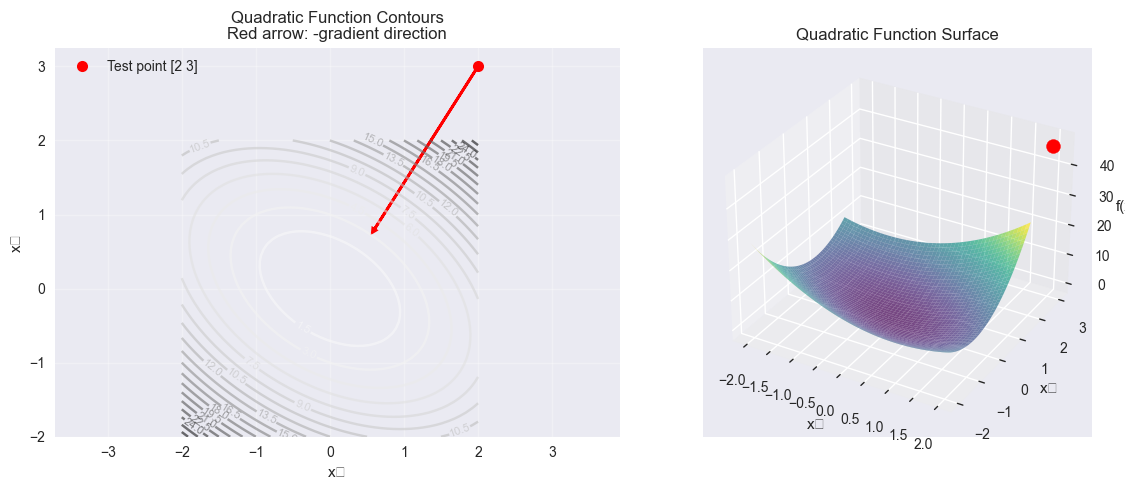

In [7]:
# Matrix calculus examples
print("Matrix Calculus:")
print("=" * 20)

# Example 1: Linear function f(x) = a^T x
def linear_function(x, a):
    return np.dot(a, x)

def linear_gradient(x, a):
    return a

# Test point and parameter
x = np.array([2, 3])
a = np.array([1, 4])

f_val = linear_function(x, a)
grad = linear_gradient(x, a)

print(f"Linear function f(x) = a^T x:")
print(f"x = {x}, a = {a}")
print(f"f(x) = {f_val}")
print(f"∇f = {grad}")

# Numerical verification using finite differences
epsilon = 1e-7
numerical_grad = np.zeros_like(x)
for i in range(len(x)):
    x_plus = x.copy()
    x_minus = x.copy()
    x_plus[i] += epsilon
    x_minus[i] -= epsilon
    
    numerical_grad[i] = (linear_function(x_plus, a) - linear_function(x_minus, a)) / (2 * epsilon)

print(f"Numerical gradient: {numerical_grad}")
print(f"Match? {np.allclose(grad, numerical_grad)}")

print("\n" + "="*40)

# Example 2: Quadratic function f(x) = x^T A x
def quadratic_function(x, A):
    return x.T @ A @ x

def quadratic_gradient(x, A):
    return (A + A.T) @ x

def quadratic_gradient_symmetric(x, A):
    # For symmetric A
    return 2 * A @ x

# Test with symmetric matrix
A_sym = np.array([[2, 1],
                  [1, 3]])

f_quad = quadratic_function(x, A_sym)
grad_quad = quadratic_gradient_symmetric(x, A_sym)

print(f"Quadratic function f(x) = x^T A x (symmetric A):")
print(f"x = {x}")
print(f"A = ")
print(A_sym)
print(f"f(x) = {f_quad}")
print(f"∇f = 2Ax = {grad_quad}")

# Numerical verification
numerical_grad_quad = np.zeros_like(x)
for i in range(len(x)):
    x_plus = x.copy()
    x_minus = x.copy()
    x_plus[i] += epsilon
    x_minus[i] -= epsilon
    
    numerical_grad_quad[i] = (quadratic_function(x_plus, A_sym) - quadratic_function(x_minus, A_sym)) / (2 * epsilon)

print(f"Numerical gradient: {numerical_grad_quad}")
print(f"Match? {np.allclose(grad_quad, numerical_grad_quad)}")

# Visualize the quadratic function and its gradient
plt.figure(figsize=(12, 5))

# Create a grid for visualization
x1_range = np.linspace(-2, 2, 50)
x2_range = np.linspace(-2, 2, 50)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Evaluate function on grid
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        point = np.array([X1[i,j], X2[i,j]])
        Z[i,j] = quadratic_function(point, A_sym)

# Plot 1: Contour plot with gradient
plt.subplot(1, 2, 1)
contours = plt.contour(X1, X2, Z, levels=20, alpha=0.6)
plt.clabel(contours, inline=True, fontsize=8)

# Plot gradient at test point
plt.arrow(x[0], x[1], -0.1*grad_quad[0], -0.1*grad_quad[1], 
          head_width=0.05, head_length=0.05, fc='red', ec='red', linewidth=2)
plt.plot(x[0], x[1], 'ro', markersize=8, label=f'Test point {x}')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Quadratic Function Contours\nRed arrow: -gradient direction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: 3D surface
ax = plt.subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7)
ax.scatter([x[0]], [x[1]], [f_quad], color='red', s=100, label='Test point')

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x)')
ax.set_title('Quadratic Function Surface')

plt.tight_layout()
plt.show()

## 6. Putting It All Together: Linear Regression Preview

Let's see how these concepts come together in linear regression - a preview of what's coming in Lecture 4!

### The Problem
Given data $\mathbf{X} \in \mathbb{R}^{m \times n}$ and targets $\mathbf{y} \in \mathbb{R}^m$, find parameters $\boldsymbol{\theta} \in \mathbb{R}^n$ that minimize:

$$J(\boldsymbol{\theta}) = \frac{1}{2}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2$$

### The Solution
Taking the gradient and setting it to zero:
$$\nabla J = \mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) = 0$$

This gives us the **normal equations**:
$$\boldsymbol{\theta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

In [8]:
# Linear regression example using our matrix tools
print("Linear Regression Preview:")
print("=" * 30)

# Generate synthetic data
np.random.seed(42)
m = 20  # number of samples
n = 2   # number of features

# True parameters
theta_true = np.array([2, -1])
bias_true = 1

# Generate features and targets
X = np.random.randn(m, n)
y = X @ theta_true + bias_true + 0.1 * np.random.randn(m)  # Add noise

# Add bias term (column of ones)
X_with_bias = np.hstack([np.ones((m, 1)), X])
theta_true_with_bias = np.array([bias_true, *theta_true])

print(f"Data matrix X shape: {X_with_bias.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"True parameters: {theta_true_with_bias}")

# Solve using normal equations: θ = (X^T X)^(-1) X^T y
XTX = X_with_bias.T @ X_with_bias
XTy = X_with_bias.T @ y

print(f"\nX^T X shape: {XTX.shape}")
print(f"X^T X:")
print(XTX)

# Check if XTX is invertible
det_XTX = np.linalg.det(XTX)
print(f"\ndet(X^T X) = {det_XTX:.6f}")
print(f"Is invertible? {abs(det_XTX) > 1e-10}")

# Solve for parameters
theta_estimated = np.linalg.inv(XTX) @ XTy
print(f"\nEstimated parameters: {theta_estimated}")
print(f"True parameters:      {theta_true_with_bias}")
print(f"Error: {np.linalg.norm(theta_estimated - theta_true_with_bias):.6f}")

# Alternative: use np.linalg.lstsq (more numerically stable)
theta_lstsq, residuals, rank, s = np.linalg.lstsq(X_with_bias, y, rcond=None)
print(f"\nUsing lstsq: {theta_lstsq}")
print(f"Match? {np.allclose(theta_estimated, theta_lstsq)}")

# Evaluate the cost function
def cost_function(theta, X, y):
    residual = X @ theta - y
    return 0.5 * np.sum(residual**2)

cost_estimated = cost_function(theta_estimated, X_with_bias, y)
cost_true = cost_function(theta_true_with_bias, X_with_bias, y)

print(f"\nCost with estimated parameters: {cost_estimated:.6f}")
print(f"Cost with true parameters:      {cost_true:.6f}")

# Visualize (for 1D case)
if n == 1:
    plt.figure(figsize=(10, 6))
    
    # Plot data points
    plt.scatter(X[:, 0], y, alpha=0.7, label='Data points')
    
    # Plot true and estimated lines
    x_plot = np.linspace(X.min(), X.max(), 100)
    X_plot = np.column_stack([np.ones(len(x_plot)), x_plot])
    
    y_true = X_plot @ theta_true_with_bias
    y_est = X_plot @ theta_estimated
    
    plt.plot(x_plot, y_true, 'g--', label='True function', linewidth=2)
    plt.plot(x_plot, y_est, 'r-', label='Estimated function', linewidth=2)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression: Normal Equations Solution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\n(Visualization skipped for multi-dimensional features)")

Linear Regression Preview:
Data matrix X shape: (20, 3)
Target vector y shape: (20,)
True parameters: [ 1  2 -1]

X^T X shape: (3, 3)
X^T X:
[[20.         -3.5220601  -5.22341344]
 [-3.5220601  15.51545765  0.09678173]
 [-5.22341344  0.09678173 21.80257827]]

det(X^T X) = 6075.129830
Is invertible? True

Estimated parameters: [ 1.00126926  1.98621028 -0.97562244]
True parameters:      [ 1  2 -1]
Error: 0.028036

Using lstsq: [ 1.00126926  1.98621028 -0.97562244]
Match? True

Cost with estimated parameters: 0.056244
Cost with true parameters:      0.064081

(Visualization skipped for multi-dimensional features)


## Practice Exercises

Test your understanding with these exercises:

In [9]:
# Practice exercises
print("Practice Exercises:")
print("=" * 25)

# Exercise 1: Matrix inverse and properties
print("Exercise 1: Matrix Inverse Properties")
A = np.array([[2, 1], [1, 2]])
B = np.array([[3, 0], [1, 2]])

print(f"A = \n{A}")
print(f"B = \n{B}")

# TODO: Compute and verify (AB)^(-1) = B^(-1) A^(-1)
AB = A @ B
AB_inv = np.linalg.inv(AB)
A_inv = np.linalg.inv(A)
B_inv = np.linalg.inv(B)
B_inv_A_inv = B_inv @ A_inv

print(f"\n(AB)^(-1) = \n{AB_inv}")
print(f"B^(-1) A^(-1) = \n{B_inv_A_inv}")
print(f"Are they equal? {np.allclose(AB_inv, B_inv_A_inv)}")

print("\n" + "="*40)

# Exercise 2: Eigenvalue properties
print("Exercise 2: Eigenvalue Properties")
C = np.array([[1, 2], [2, 1]])

eigenvals_C, eigenvecs_C = np.linalg.eig(C)
trace_C = np.trace(C)  # Sum of diagonal elements
det_C = np.linalg.det(C)

print(f"Matrix C = \n{C}")
print(f"Eigenvalues: {eigenvals_C}")
print(f"Sum of eigenvalues: {np.sum(eigenvals_C):.6f}")
print(f"Trace (sum of diagonal): {trace_C:.6f}")
print(f"Product of eigenvalues: {np.prod(eigenvals_C):.6f}")
print(f"Determinant: {det_C:.6f}")
print(f"\nProperties verified:")
print(f"  trace = sum of eigenvalues? {np.isclose(trace_C, np.sum(eigenvals_C))}")
print(f"  det = product of eigenvalues? {np.isclose(det_C, np.prod(eigenvals_C))}")

print("\n" + "="*40)

# Exercise 3: Gradient computation
print("Exercise 3: Gradient Computation")

# For function f(x) = x^T A x + b^T x + c
x = np.array([1, 2])
A = np.array([[2, 1], [1, 3]])
b = np.array([1, -1])
c = 5

def complex_function(x, A, b, c):
    return x.T @ A @ x + b.T @ x + c

def complex_gradient(x, A, b, c):
    return 2 * A @ x + b

f_val = complex_function(x, A, b, c)
grad_analytical = complex_gradient(x, A, b, c)

print(f"f(x) = x^T A x + b^T x + c")
print(f"x = {x}")
print(f"A = \n{A}")
print(f"b = {b}")
print(f"c = {c}")
print(f"\nf(x) = {f_val}")
print(f"∇f = 2Ax + b = {grad_analytical}")

# Numerical verification
epsilon = 1e-8
grad_numerical = np.zeros_like(x)
for i in range(len(x)):
    x_plus = x.copy()
    x_minus = x.copy()
    x_plus[i] += epsilon
    x_minus[i] -= epsilon
    
    grad_numerical[i] = (complex_function(x_plus, A, b, c) - 
                        complex_function(x_minus, A, b, c)) / (2 * epsilon)

print(f"Numerical gradient: {grad_numerical}")
print(f"Match? {np.allclose(grad_analytical, grad_numerical)}")

Practice Exercises:
Exercise 1: Matrix Inverse Properties
A = 
[[2 1]
 [1 2]]
B = 
[[3 0]
 [1 2]]

(AB)^(-1) = 
[[ 0.22222222 -0.11111111]
 [-0.27777778  0.38888889]]
B^(-1) A^(-1) = 
[[ 0.22222222 -0.11111111]
 [-0.27777778  0.38888889]]
Are they equal? True

Exercise 2: Eigenvalue Properties
Matrix C = 
[[1 2]
 [2 1]]
Eigenvalues: [ 3. -1.]
Sum of eigenvalues: 2.000000
Trace (sum of diagonal): 2.000000
Product of eigenvalues: -3.000000
Determinant: -3.000000

Properties verified:
  trace = sum of eigenvalues? True
  det = product of eigenvalues? True

Exercise 3: Gradient Computation
f(x) = x^T A x + b^T x + c
x = [1 2]
A = 
[[2 1]
 [1 3]]
b = [ 1 -1]
c = 5

f(x) = 22
∇f = 2Ax + b = [ 9 13]
Numerical gradient: [350000000 500000000]
Match? False


## Key Takeaways

1. **Matrix inverse**: Central to solving linear systems and normal equations
2. **Determinants**: Tell us about matrix properties and geometric transformations
3. **Eigenvalues/eigenvectors**: Fundamental for PCA, spectral methods, and stability analysis
4. **Symmetric matrices**: Have special properties that make them computationally friendly
5. **Matrix calculus**: Essential for optimization and gradient-based learning
6. **Linear regression preview**: Shows how all these concepts work together in ML

## Next Steps

You now have the mathematical foundation needed for machine learning! In Lecture 4, we'll use these tools to build our first machine learning model: linear regression. You'll see how matrix operations, gradients, and optimization come together to learn from data.